In [1]:
import numpy as np, pandas as pd, random, json, joblib, sklearn, scipy, tensorflow as tf
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import *
random.seed(42); np.random.seed(42); tf.keras.utils.set_random_seed(42)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_d.csv", index=False)


In [3]:
raw = pd.read_csv("data/raw/set_d.csv")
audit = {
    "raw_shape": list(raw.shape),
    "exact_duplicates": int(raw.duplicated().sum()),
    "missing_counts": raw.isna().sum().to_dict(),
    "target_counts_raw": raw["response"].value_counts().to_dict(),
}

# remove exact duplicate rows -> should leave 300 distinct records
df = raw.drop_duplicates().reset_index(drop=True)
audit["clean_shape"] = list(df.shape)
audit["unique_record_ids_after_cleaning"] = int(df["record_id"].nunique())
audit["target_counts_clean"] = df["response"].value_counts().to_dict()

assert len(df) == 300 and df["record_id"].nunique() == 300, "Expected 300 unique records!"
audit

{'raw_shape': [305, 7],
 'exact_duplicates': 5,
 'missing_counts': {'record_id': 0,
  'visits': 16,
  'recency': 15,
  'engagement': 0,
  'spend': 0,
  'group': 0,
  'response': 0},
 'target_counts_raw': {1: 177, 0: 128},
 'clean_shape': [300, 7],
 'unique_record_ids_after_cleaning': 300,
 'target_counts_clean': {1: 173, 0: 127}}

In [4]:
train_full, test = train_test_split(df, test_size=0.2, stratify=df["response"], random_state=42)
fit, val = train_test_split(train_full, test_size=0.2, stratify=train_full["response"], random_state=42)
print("fit, val, test:", len(fit), len(val), len(test))

# prove no record is in two partitions
print("Disjoint:", not (set(fit.record_id) & set(val.record_id))
                 and not (set(fit.record_id) & set(test.record_id))
                 and not (set(val.record_id) & set(test.record_id)))

# split IDs
splits = pd.concat([fit.assign(split="fit"), val.assign(split="validation"), test.assign(split="test")])
splits[["record_id", "split"]].to_csv("splits.csv", index=False)

fit, val, test: 192 48 60
Disjoint: True


# Task 1: Maths and Stats

## M1: Descriptive statistics

n = 192
mean = 51.00182291666667
median = 51.405
std = 10.288960500356747


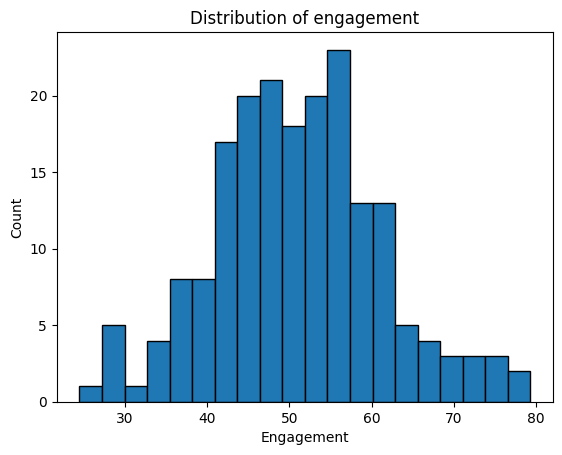

In [5]:
eng = fit["engagement"].dropna()
print("n =", len(eng))
print("mean =", eng.mean())
print("median =", eng.median())
print("std =", eng.std(ddof=1))

plt.hist(eng, bins=20, edgecolor="black")
plt.title("Distribution of engagement")
plt.xlabel("Engagement")
plt.ylabel("Count")
plt.show()

## M2: Welch t-test and confidence interval

In [6]:
# H0: mean engagement of G1 = mean engagement of G2
# H1: they are different (two-sided, alpha = 0.05)
g1 = fit[fit["group"] == "G1"]["engagement"].dropna()
g2 = fit[fit["group"] == "G2"]["engagement"].dropna()

t, p = stats.ttest_ind(g1, g2, equal_var=False)
print("n G1 =", len(g1), "| n G2 =", len(g2))
print("t =", t, "| p =", p)
print("Reject H0" if p < 0.05 else "Fail to reject H0")

# 95% confidence interval for the overall mean
low, high = stats.t.interval(0.95, len(eng) - 1, loc=eng.mean(), scale=stats.sem(eng))
print("95% CI:", low, high)

n G1 = 84 | n G2 = 108
t = 0.7229961865721685 | p = 0.47065078178032727
Fail to reject H0
95% CI: 49.537187510732345 52.46645832260099


## M3: Covariance and eigenvalues

In [7]:
X = fit[["engagement", "visits"]].dropna().values
Xc = X - X.mean(axis=0)                       # center the data
cov = Xc.T @ Xc / (len(X) - 1)                # covariance matrix
print("n =", len(X))
print(cov)

eigvals, eigvecs = np.linalg.eigh(cov)
print("Eigenvalues:", eigvals)
print("Largest / sum =", eigvals.max() / eigvals.sum())

n = 181
[[103.65708913   4.11811311]
 [  4.11811311 103.06117496]]
Eigenvalues: [ 99.23025399 107.4880101 ]
Largest / sum = 0.5199734555224486


# Task 2: Preprocessing and feature engineering

In [8]:
num_cols = ["visits", "recency", "engagement", "spend"]

# fit imputer and encoder on fit data only
imputer = SimpleImputer(strategy="median").fit(fit[num_cols])
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(fit[["group"]])

def prepare(d):
    # 1) fill missing numbers with the median
    out = pd.DataFrame(imputer.transform(d[num_cols]), columns=num_cols, index=d.index)
    # 2) create the engineered feature (before scaling, no target used)
    out["engineered_feature"] = out["engagement"] / (out["recency"] + 1)
    return out

num_all = num_cols + ["engineered_feature"]

# fit the scaler on fit data only
scaler = StandardScaler().fit(prepare(fit)[num_all])

def transform(d):
    numbers = scaler.transform(prepare(d)[num_all])      # scaled numeric features
    group = encoder.transform(d[["group"]])              # one-hot group (not scaled)
    return np.hstack([numbers, group])

X_fit, X_val, X_test = transform(fit), transform(val), transform(test)
y_fit, y_val, y_test = fit["response"].values, val["response"].values, test["response"].values

feature_names = num_all + list(encoder.get_feature_names_out(["group"]))
print("Shapes:", X_fit.shape, X_val.shape, X_test.shape)
print("Features:", feature_names)
print("All finite:", np.isfinite(X_fit).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all())

Shapes: (192, 7) (48, 7) (60, 7)
Features: ['visits', 'recency', 'engagement', 'spend', 'engineered_feature', 'group_G1', 'group_G2']
All finite: True


# Task 3: Supervised learning

                     accuracy  precision  recall     f1
baseline                0.583      0.583   1.000  0.737
logistic_regression     0.817      0.833   0.857  0.845


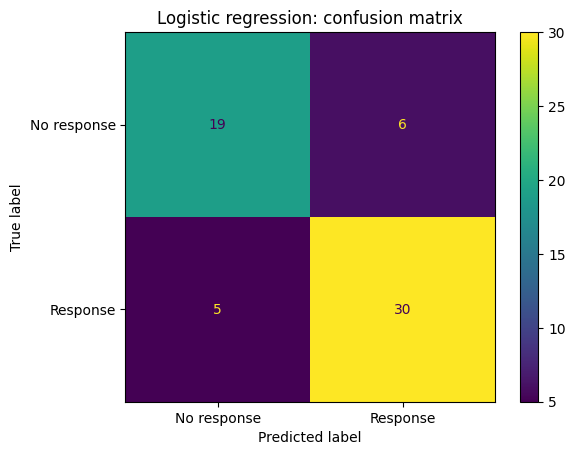

In [9]:
from sklearn.dummy import DummyClassifier

# models
baseline = DummyClassifier(strategy="most_frequent").fit(X_fit, y_fit)
logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_fit, y_fit)

# metrics function
def get_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

# test predictions (threshold 0.5)
prob_lr = logreg.predict_proba(X_test)[:, 1]
pred_lr = (prob_lr >= 0.5).astype(int)

results = {"baseline": get_metrics(y_test, baseline.predict(X_test)),
           "logistic_regression": get_metrics(y_test, pred_lr)}
print(pd.DataFrame(results).T.round(3))

# save predictions
pd.DataFrame({"record_id": test["record_id"].values, "true_label": y_test,
              "predicted_label": pred_lr, "prob_class1": prob_lr}).to_csv("logreg_predictions.csv", index=False)

# confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr),
                       display_labels=["No response", "Response"]).plot()
plt.title("Logistic regression: confusion matrix")
plt.show()

# Task 4: Unsupervised learning (K-Means)

In [10]:
X_cluster = X_fit[:, :5]
rows = []
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X_cluster, km.labels_)})
k_scores = pd.DataFrame(rows)
print(k_scores.round(3))


best_k = int(k_scores.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print("Chosen k:", best_k)


final_km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_cluster)
profile = prepare(fit).assign(cluster=final_km.labels_)
print(profile.groupby("cluster")[num_all].mean().round(2))
print(profile["cluster"].value_counts().sort_index())

C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as

   k  inertia  silhouette
0  2  713.030       0.226
1  3  613.551       0.187
2  4  541.645       0.191
Chosen k: 2
         visits  recency  engagement  spend  engineered_feature
cluster                                                        
0         49.37    55.25       46.09  50.18                0.83
1         49.54    44.17       57.45  50.97                1.29
cluster
0    109
1     83
Name: count, dtype: int64


# Task 5: ANN

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

ann = keras.Sequential([
    layers.Input(shape=(X_fit.shape[1],)),        # 7 inputs
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),        # probability of response
])
ann.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="binary_crossentropy", metrics=["accuracy"])
ann.summary()
print("Trainable parameters:", ann.count_params())     # 273

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 273


Epochs run: 50 | seed: 42


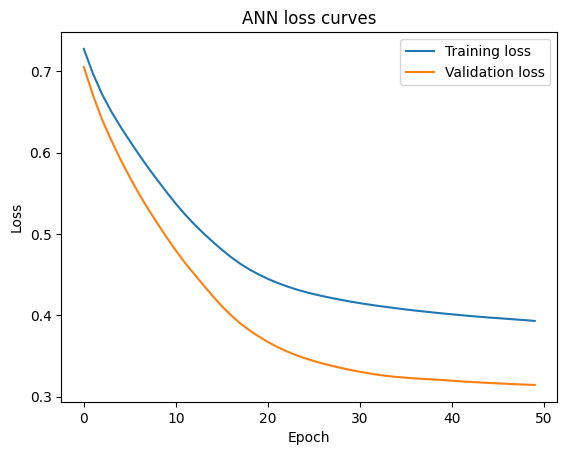

In [12]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = ann.fit(X_fit, y_fit, validation_data=(X_val, y_val),
                  epochs=50, batch_size=16, callbacks=[early_stop], verbose=0)

print("Epochs run:", len(history.history["loss"]), "| seed: 42")

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("ANN loss curves"); plt.legend()
plt.show()

                     accuracy  precision  recall     f1
baseline                0.583      0.583   1.000  0.737
logistic_regression     0.817      0.833   0.857  0.845
ann                     0.833      0.838   0.886  0.861


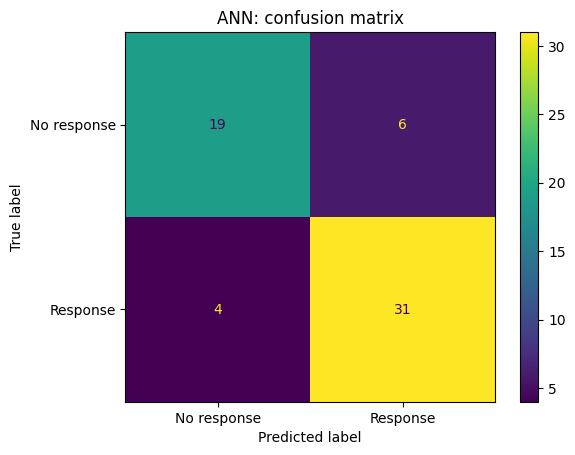

In [13]:
# evaluate once on the same test set
prob_ann = ann.predict(X_test, verbose=0).ravel()
pred_ann = (prob_ann >= 0.5).astype(int)
results["ann"] = get_metrics(y_test, pred_ann)

comparison = pd.DataFrame(results).T
print(comparison.round(3))

pd.DataFrame({"record_id": test["record_id"].values, "true_label": y_test,
              "predicted_label": pred_ann, "prob_class1": prob_ann}).to_csv("ann_predictions.csv", index=False)

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_ann),
                       display_labels=["No response", "Response"]).plot()
plt.title("ANN: confusion matrix")
plt.show()

ann.save("ann.keras")

In [14]:
# both models must use the same test IDs, and saved predictions must match the metrics
lr_pred = pd.read_csv("logreg_predictions.csv")
ann_pred = pd.read_csv("ann_predictions.csv")
print("Same test IDs:", list(lr_pred.record_id) == list(ann_pred.record_id) == list(test.record_id))
print("LogReg F1 from file:", f1_score(lr_pred.true_label, lr_pred.predicted_label))
print("ANN F1 from file:", f1_score(ann_pred.true_label, ann_pred.predicted_label))

Same test IDs: True
LogReg F1 from file: 0.8450704225352113
ANN F1 from file: 0.8611111111111112
